# AI-Based Faculty Attendance System

## YOLO-Based Face Detection

This notebook trains a YOLO11 model to detect human faces
for an automated faculty attendance system.

### Pipeline

Camera
↓
YOLO Face Detection
↓
Face Crop
↓
Face Recognition
↓
Faculty Identification
↓
Attendance


In [4]:
# ============================================================
# 🚀 FACULTY ATTENDANCE - AUTO SETUP
# ============================================================

import os
import sys
import subprocess
import importlib.util

# Mount Drive
from google.colab import drive
drive.mount("/content/drive")

# Project paths
PROJECT_DIR = "/content/drive/MyDrive/face_attendance_project"

MODEL_PATH = (
    f"{PROJECT_DIR}/"
    "wider_face_20/"
    "weights/"
    "best.pt"
)

REQUIREMENTS_PATH = (
    f"{PROJECT_DIR}/"
    "environment/"
    "requirements.txt"
)

# Install dependencies if necessary
if not importlib.util.find_spec("ultralytics"):

    print("📦 Installing dependencies...")

    subprocess.check_call([
        sys.executable,
        "-m",
        "pip",
        "install",
        "-q",
        "-r",
        REQUIREMENTS_PATH
    ])

    print("✅ Dependencies installed")

else:
    print("✅ Dependencies already available")

# Imports
from ultralytics import YOLO
import cv2
import numpy as np

from PIL import Image
from IPython.display import display, Javascript, clear_output
from google.colab.output import eval_js
from base64 import b64decode

# Check model
if not os.path.exists(MODEL_PATH):
    raise FileNotFoundError(
        f"❌ best.pt not found:\n{MODEL_PATH}"
    )

# Load trained model
model = YOLO(MODEL_PATH)

print()
print("=" * 60)
print("✅ FACULTY ATTENDANCE SYSTEM READY")
print("=" * 60)
print("🧠 YOLO model loaded")
print("📁", MODEL_PATH)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Dependencies already available

✅ FACULTY ATTENDANCE SYSTEM READY
🧠 YOLO model loaded
📁 /content/drive/MyDrive/face_attendance_project/wider_face_20/weights/best.pt


📷 Starting webcam...
⏳ Please allow camera permission if requested.


<IPython.core.display.Javascript object>

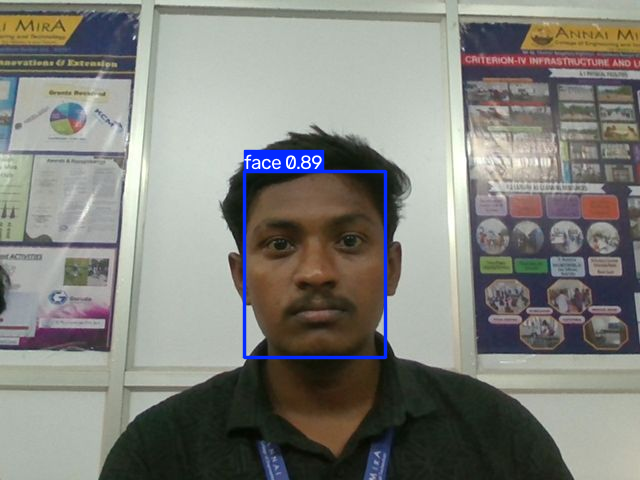


👤 Faces detected: 1


In [5]:
# ============================================================
# 📷 AUTOMATIC WEBCAM FACE DETECTION
# ============================================================

from ultralytics import YOLO
from IPython.display import display, Javascript
from google.colab.output import eval_js
from base64 import b64decode

import cv2
import numpy as np
from PIL import Image
import time


def take_photo(quality=0.8):

    js = Javascript("""
    async function takePhoto(quality) {

        const div = document.createElement('div');
        const video = document.createElement('video');

        video.style.display = 'block';
        video.width = 640;
        video.height = 480;

        const stream =
            await navigator.mediaDevices.getUserMedia({
                video: true,
                audio: false
            });

        document.body.appendChild(div);
        div.appendChild(video);

        video.srcObject = stream;

        await video.play();

        // Allow camera to stabilize
        await new Promise(resolve =>
            setTimeout(resolve, 1000)
        );

        const canvas =
            document.createElement('canvas');

        canvas.width = video.videoWidth;
        canvas.height = video.videoHeight;

        canvas
            .getContext('2d')
            .drawImage(video, 0, 0);

        const image =
            canvas.toDataURL(
                'image/jpeg',
                quality
            );

        // Stop camera
        stream
            .getVideoTracks()[0]
            .stop();

        div.remove();

        return image;
    }
    """)

    display(js)

    data = eval_js(
        f"takePhoto({quality})"
    )

    binary = b64decode(
        data.split(',')[1]
    )

    return np.frombuffer(
        binary,
        dtype=np.uint8
    )


# ============================================================
# 🚀 START AUTOMATIC DETECTION
# ============================================================

print("📷 Starting webcam...")
print("⏳ Please allow camera permission if requested.")

frame = take_photo(0.8)

image = cv2.imdecode(
    frame,
    cv2.IMREAD_COLOR
)

# ============================================================
# 🧠 YOLO DETECTION
# ============================================================

results = model.predict(
    source=image,
    conf=0.25,
    imgsz=640,
    verbose=False
)

# Draw detections
annotated = results[0].plot()

# Convert BGR → RGB
annotated = cv2.cvtColor(
    annotated,
    cv2.COLOR_BGR2RGB
)

# ============================================================
# 📊 RESULT
# ============================================================

display(
    Image.fromarray(annotated)
)

face_count = len(
    results[0].boxes
)

print()
print("=" * 50)
print(f"👤 Faces detected: {face_count}")
print("=" * 50)

In [6]:
# ============================================================
# FACULTY ATTENDANCE - AUTOMATIC ENVIRONMENT SETUP
# ============================================================

import os
import sys
import subprocess
import importlib.util


# ------------------------------------------------------------
# STEP 1 — Mount Google Drive
# ------------------------------------------------------------

from google.colab import drive

drive.mount("/content/drive")

print("✅ Google Drive connected")


# ------------------------------------------------------------
# STEP 2 — Project paths
# ------------------------------------------------------------

PROJECT_DIR = (
    "/content/drive/MyDrive/"
    "face_attendance_project"
)

MODEL_PATH = (
    f"{PROJECT_DIR}/"
    "wider_face_20/"
    "weights/"
    "best.pt"
)

REQUIREMENTS_PATH = (
    f"{PROJECT_DIR}/"
    "environment/"
    "requirements.txt"
)


# ------------------------------------------------------------
# STEP 3 — Install dependencies automatically
# ------------------------------------------------------------

if not importlib.util.find_spec("ultralytics"):

    print("📦 Ultralytics not found")
    print("📦 Installing dependencies...")

    subprocess.check_call([
        sys.executable,
        "-m",
        "pip",
        "install",
        "-q",
        "-r",
        REQUIREMENTS_PATH
    ])

    print("✅ Dependencies installed")

else:

    print("✅ Ultralytics already installed")


# ------------------------------------------------------------
# STEP 4 — Import libraries
# ------------------------------------------------------------

from ultralytics import YOLO

import cv2
import numpy as np

from PIL import Image

from IPython.display import (
    display,
    Javascript,
    clear_output
)

from google.colab.output import eval_js

from base64 import b64decode


# ------------------------------------------------------------
# STEP 5 — Check model
# ------------------------------------------------------------

if not os.path.exists(MODEL_PATH):

    raise FileNotFoundError(
        f"""
❌ Model not found!

Expected:
{MODEL_PATH}
"""
    )


# ------------------------------------------------------------
# STEP 6 — Load trained model
# ------------------------------------------------------------

print("🧠 Loading trained YOLO model...")

model = YOLO(MODEL_PATH)


# ------------------------------------------------------------
# COMPLETE
# ------------------------------------------------------------

print()
print("=" * 60)
print("✅ FACULTY ATTENDANCE ENVIRONMENT READY")
print("=" * 60)

print("📦 Ultralytics: Ready")
print("🧠 YOLO model: Loaded")
print("📁 Model:", MODEL_PATH)
print()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Google Drive connected
✅ Ultralytics already installed
🧠 Loading trained YOLO model...

✅ FACULTY ATTENDANCE ENVIRONMENT READY
📦 Ultralytics: Ready
🧠 YOLO model: Loaded
📁 Model: /content/drive/MyDrive/face_attendance_project/wider_face_20/weights/best.pt



In [7]:
import torch

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("WARNING: GPU not available")

PyTorch version: 2.11.0+cu128
CUDA available: True
GPU: Tesla T4


### Installing YOLO

In [8]:
!pip install -q ultralytics

In [9]:
import ultralytics

print("Ultralytics version:", ultralytics.__version__)

Ultralytics version: 8.4.161


### Importing libraries

In [10]:
from ultralytics import YOLO

import os
import shutil
import random
import yaml
import cv2
import matplotlib.pyplot as plt

from pathlib import Path

KAGGLE DATASET


In [11]:
!pip install -q kaggle

In [ ]:
from google.colab import files

files.upload()

In [ ]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
!kaggle datasets list -s wider-face

In [ ]:
!kaggle datasets download -d lylmsc/wider-face-for-yolo-training

In [ ]:
!unzip -q wider-face-for-yolo-training.zip -d /content/wider-face

In [ ]:
!find /content/wider-face -maxdepth 3 -type f | head -50

In [ ]:
!find /content/wider-face -maxdepth 3 -type f | head -50

In [ ]:
!find /content/wider-face -name "*.yaml" -o -name "*.yml"

In [ ]:
!cat /content/wider-face/data.yaml

In [ ]:
!find /content/wider-face -maxdepth 4 -type d

In [ ]:
!find /content/wider-face -maxdepth 3 -type f | head -100

In [ ]:
!find /content/wider-face -type f -name "*.txt" | head -20

In [ ]:
!find /content/wider-face -type f \( -name "*.jpg" -o -name "*.jpeg" -o -name "*.png" \) | head -20

In [ ]:
!ls -lah /content/wider-face

In [ ]:
!find /content/wider-face/images -maxdepth 2 -type d

In [ ]:
!find /content/wider-face/labels -maxdepth 2 -type d

In [ ]:
!find /content/wider-face/images -type f | head -10

In [ ]:
!find /content/wider-face/labels -type f | head -10

In [ ]:
!cat /content/wider-face/labels/train/<filename>.txt

In [ ]:
import glob

label_files = glob.glob("/content/wider-face/labels/**/*.txt", recursive=True)

print("Number of label files:", len(label_files))

if label_files:
    print("First label file:", label_files[0])
    print("\nContents:\n")
    with open(label_files[0], "r") as f:
        print(f.read())

In [ ]:
import os

for root, dirs, files in os.walk("/content/wider-face"):
    level = root.replace("/content/wider-face", "").count(os.sep)
    if level <= 2:
        print("  " * level + os.path.basename(root) + "/")

In [ ]:
import glob
import os

image_files = glob.glob("/content/wider-face/images/**/*", recursive=True)

image_files = [
    f for f in image_files
    if f.lower().endswith((".jpg", ".jpeg", ".png"))
]

print("Number of images:", len(image_files))
print("\nFirst 10 images:")

for f in image_files[:10]:
    print(f)

In [ ]:
import glob
import os

label_files = glob.glob("/content/wider-face/labels/*.txt")

print("Labels:", len(label_files))

for f in label_files[:10]:
    print(os.path.basename(f))

In [ ]:
image_files = glob.glob("/content/wider-face/images/**/*", recursive=True)

image_files = [
    f for f in image_files
    if f.lower().endswith((".jpg", ".jpeg", ".png"))
]

for f in image_files[:10]:
    print(os.path.basename(f))

In [ ]:
import glob
import os

images = glob.glob("/content/wider-face/images/**/*", recursive=True)
images = [
    f for f in images
    if f.lower().endswith((".jpg", ".jpeg", ".png"))
]

labels = glob.glob("/content/wider-face/labels/*.txt")

image_names = {
    os.path.splitext(os.path.basename(f))[0]
    for f in images
}

label_names = {
    os.path.splitext(os.path.basename(f))[0]
    for f in labels
}

matched = image_names & label_names
unmatched_images = image_names - label_names
unmatched_labels = label_names - image_names

print("Images:", len(image_names))
print("Labels:", len(label_names))
print("Matched:", len(matched))
print("Images without labels:", len(unmatched_images))
print("Labels without images:", len(unmatched_labels))

In [ ]:
import os
import glob
import shutil
import random

# Original dataset
IMAGE_DIR = "/content/wider-face/images"
LABEL_DIR = "/content/wider-face/labels"

# New YOLO dataset
OUTPUT_DIR = "/content/yolo_dataset"

# Create folders
for folder in [
    "images/train",
    "images/val",
    "labels/train",
    "labels/val"
]:
    os.makedirs(os.path.join(OUTPUT_DIR, folder), exist_ok=True)

# Get all images
images = glob.glob(os.path.join(IMAGE_DIR, "*.jpg"))

print("Total images:", len(images))

# Shuffle
random.seed(42)
random.shuffle(images)

# 80/20 split
split_index = int(len(images) * 0.8)

train_images = images[:split_index]
val_images = images[split_index:]

print("Training images:", len(train_images))
print("Validation images:", len(val_images))

# Copy files
for image_path in train_images:

    filename = os.path.basename(image_path)
    name = os.path.splitext(filename)[0]

    label_path = os.path.join(LABEL_DIR, name + ".txt")

    shutil.copy(
        image_path,
        os.path.join(OUTPUT_DIR, "images/train", filename)
    )

    shutil.copy(
        label_path,
        os.path.join(OUTPUT_DIR, "labels/train", name + ".txt")
    )


for image_path in val_images:

    filename = os.path.basename(image_path)
    name = os.path.splitext(filename)[0]

    label_path = os.path.join(LABEL_DIR, name + ".txt")

    shutil.copy(
        image_path,
        os.path.join(OUTPUT_DIR, "images/val", filename)
    )

    shutil.copy(
        label_path,
        os.path.join(OUTPUT_DIR, "labels/val", name + ".txt")
    )

print("Dataset preparation completed!")

In [ ]:
yaml_content = """
path: /content/yolo_dataset

train: images/train
val: images/val

nc: 1

names:
  0: face
"""

with open("/content/yolo_dataset/data.yaml", "w") as f:
    f.write(yaml_content)

print("data.yaml created successfully!")

In [ ]:
!cat /content/yolo_dataset/data.yaml

In [ ]:
import os
import glob
import shutil
import random

IMAGE_DIR = "/content/wider-face/images"
LABEL_DIR = "/content/wider-face/labels"
OUTPUT_DIR = "/content/yolo_dataset"

# Create folders
for folder in [
    "images/train",
    "images/val",
    "labels/train",
    "labels/val"
]:
    os.makedirs(os.path.join(OUTPUT_DIR, folder), exist_ok=True)

# Get images
images = glob.glob(os.path.join(IMAGE_DIR, "*.jpg"))

print("Total images:", len(images))

# Shuffle consistently
random.seed(42)
random.shuffle(images)

# 80% train, 20% validation
split = int(len(images) * 0.8)

train_images = images[:split]
val_images = images[split:]

print("Train:", len(train_images))
print("Validation:", len(val_images))

# Copy training files
for image_path in train_images:
    filename = os.path.basename(image_path)
    name = os.path.splitext(filename)[0]

    label_path = os.path.join(LABEL_DIR, name + ".txt")

    shutil.copy2(
        image_path,
        os.path.join(OUTPUT_DIR, "images/train", filename)
    )

    shutil.copy2(
        label_path,
        os.path.join(OUTPUT_DIR, "labels/train", name + ".txt")
    )

# Copy validation files
for image_path in val_images:
    filename = os.path.basename(image_path)
    name = os.path.splitext(filename)[0]

    label_path = os.path.join(LABEL_DIR, name + ".txt")

    shutil.copy2(
        image_path,
        os.path.join(OUTPUT_DIR, "images/val", filename)
    )

    shutil.copy2(
        label_path,
        os.path.join(OUTPUT_DIR, "labels/val", name + ".txt")
    )

print("✅ Dataset preparation completed!")

In [ ]:
yaml_content = """
path: /content/yolo_dataset

train: images/train
val: images/val

nc: 1

names:
  0: face
"""

with open("/content/yolo_dataset/data.yaml", "w") as f:
    f.write(yaml_content)

print("✅ data.yaml created")

In [ ]:
!cat /content/yolo_dataset/data.yaml

In [ ]:
!pip install -q -U ultralytics

In [ ]:
import ultralytics

print("Ultralytics version:", ultralytics.__version__)

In [ ]:
from ultralytics import YOLO

print("YOLO is ready!")

In [ ]:
import torch

print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

In [ ]:
from ultralytics import YOLO

model = YOLO("yolo11n.pt")

print("Model loaded successfully!")

In [ ]:
import os

print(os.path.exists("/content/yolo_dataset/data.yaml"))
print(os.path.exists("/content/yolo_dataset/images/train"))
print(os.path.exists("/content/yolo_dataset/images/val"))

In [ ]:
from ultralytics import YOLO

model = YOLO("yolo11n.pt")

In [ ]:
results = model.train(
    data="/content/yolo_dataset/data.yaml",
    epochs=20=,
    imgsz=640,
    batch=16,
    device=0,
    workers=2,
    project="/content/face_detection_training",
    name="wider_face"
)

In [ ]:
!ls -lh /content/face_detection_training/wider_face/weights/

In [ ]:
from ultralytics import YOLO

model = YOLO(
    "/content/face_detection_training/wider_face/weights/best.pt"
)

In [ ]:
metrics = model.val(
    data="/content/yolo_dataset/data.yaml",
    imgsz=640,
    batch=16,
    device=0
)

In [ ]:
from google.colab import drive
drive.mount("/content/drive")

In [ ]:
import os
import shutil

source = "/content/face_detection_training/wider_face-2"
destination = "/content/drive/MyDrive/face_attendance_project/wider_face_20"

if not os.path.exists(destination):
    shutil.copytree(source, destination)
    print("✅ Training backup completed")
else:
    print("⚠️ Backup already exists")

In [ ]:
import os
import shutil

source = "/content/yolo_dataset"
destination = "/content/drive/MyDrive/face_attendance_project/yolo_dataset"

if not os.path.exists(destination):
    shutil.copytree(source, destination)
    print("✅ Dataset backup completed")
else:
    print("⚠️ Dataset already exists")

In [ ]:
!pip install -q ultralytics

In [ ]:
import cv2
import matplotlib.pyplot as plt
from ultralytics import YOLO

# Load your trained YOLO model
model = YOLO('runs/detect/train/weights/best.pt')

# Test image path
image_path = 'path/to/test_classroom_image.jpg'
image = cv2.imread(image_path)
results = model(image_path)[0]

cropped_faces = []

for i, box in enumerate(results.boxes):
    # Extract coordinates (x1, y1, x2, y2)
    x1, y1, x2, y2 = map(int, box.xyxy[0])

    # Crop face region
    face_crop = image[y1:y2, x1:x2]
    cropped_faces.append(face_crop)

    # Save cropped face
    cv2.imwrite(f'face_{i}.jpg', face_crop)

print(f"Extracted {len(cropped_faces)} faces.")

In [ ]:
import os
from google.colab import drive

drive.mount('/content/drive')

# Path where you saved your model in Drive
drive_weights_path = '/content/drive/MyDrive/YOLO_Faculty_Attendance/best.pt'

if os.path.exists(drive_weights_path):
    print(" Found saved weights in Google Drive!")
else:
    print(" No saved weights found in Drive. You will need to retrain the model.")

In [ ]:
import os

for root, dirs, files in os.walk("/content"):
    for file in files:
        if file.endswith((".pth", ".pt", ".ckpt", ".bin", ".safetensors")):
            print(os.path.join(root, file))

In [ ]:
import os

for root, dirs, files in os.walk("/content/drive/MyDrive"):
    for file in files:
        if file.endswith((".pth", ".pt", ".ckpt", ".bin", ".safetensors")):
            print(os.path.join(root, file))

In [ ]:
WEIGHTS_PATH = "/content/drive/MyDrive/face_attendance_project/wider_face_20/weights/best.pt"

In [ ]:
from ultralytics import YOLO

model = YOLO("/content/drive/MyDrive/face_attendance_project/wider_face_20/weights/best.pt")

print("Model loaded successfully!")

In [ ]:
results = model("/content/test.jpg", conf=0.25)

results[0].show()

In [ ]:
import os

for root, dirs, files in os.walk("/content/drive/MyDrive/face_attendance_project"):
    for file in files:
        if file.lower().endswith((".jpg", ".jpeg", ".png", ".webp")):
            print(os.path.join(root, file))

In [ ]:
image_path = "/content/drive/MyDrive/face_attendance_project/test/image1.jpg"

results = model(image_path, conf=0.25)

results[0].show()

In [ ]:
import os

project = "/content/drive/MyDrive/face_attendance_project"

for root, dirs, files in os.walk(project):
    image_files = [
        f for f in files
        if f.lower().endswith((".jpg", ".jpeg", ".png", ".webp"))
    ]

    if image_files:
        print(f"\n📁 {root}")
        for f in image_files[:10]:
            print("   ", f)

In [ ]:
image_path = "/content/drive/MyDrive/face_attendance_project/wider_face_20/valid/images/10.jpg"

results = model(image_path, conf=0.25)

results[0].show()

In [ ]:
import os

project = "/content/drive/MyDrive/face_attendance_project"

print("Searching for images...\n")

count = 0

for root, dirs, files in os.walk(project):
    for file in files:
        if file.lower().endswith((".jpg", ".jpeg", ".png", ".webp", ".bmp")):
            print(os.path.join(root, file))
            count += 1

            if count >= 20:
                break

    if count >= 20:
        break

print(f"\nFound at least {count} image(s).")

In [ ]:
import os

base = "/content/drive/MyDrive/face_attendance_project/wider_face_20"

print("Folders inside wider_face_20:\n")

for item in os.listdir(base):
    path = os.path.join(base, item)
    if os.path.isdir(path):
        print("📁", item)

In [ ]:
import os

base = "/content/drive/MyDrive/face_attendance_project/wider_face_20"

for root, dirs, files in os.walk(base):
    for file in files:
        if file.endswith((".yaml", ".yml")):
            print(os.path.join(root, file))

In [ ]:
yaml_path = "/content/drive/MyDrive/face_attendance_project/wider_face_20/data.yaml"

with open(yaml_path, "r") as f:
    print(f.read())

In [ ]:
import os

project = "/content/drive/MyDrive/face_attendance_project"

yaml_files = []

for root, dirs, files in os.walk(project):
    for file in files:
        if file.lower().endswith((".yaml", ".yml")):
            yaml_files.append(os.path.join(root, file))

print("YAML files found:\n")

if yaml_files:
    for path in yaml_files:
        print(path)
else:
    print("❌ No YAML files found.")

In [ ]:
yaml_path = "/content/drive/MyDrive/face_attendance_project/wider_face_20/args.yaml"

with open(yaml_path, "r") as f:
    print(f.read())

In [ ]:
import os

print("Dataset exists:", os.path.exists("/content/yolo_dataset"))
print("data.yaml exists:", os.path.exists("/content/yolo_dataset/data.yaml"))

In [ ]:
from ultralytics import YOLO
import os

weights = "/content/drive/MyDrive/face_attendance_project/wider_face_20/weights/best.pt"

print("Weights exist:", os.path.exists(weights))

model = YOLO(weights)

print("✅ Model loaded successfully")

In [ ]:
import os

base = "/content/drive/MyDrive/face_attendance_project"

print("Searching Google Drive for original images...\n")

count = 0

for root, dirs, files in os.walk(base):
    for file in files:
        if file.lower().endswith((".jpg", ".jpeg", ".png", ".webp", ".bmp")):
            print(os.path.join(root, file))
            count += 1

print(f"\nTotal images found: {count}")

In [ ]:
image_path = "PASTE_THE_EXACT_IMAGE_PATH_HERE"

results = model(image_path, conf=0.25, save=True)

results[0].show()

In [ ]:
from google.colab import files
from ultralytics import YOLO
import os

# 1. Load your trained model
weights = "/content/drive/MyDrive/face_attendance_project/wider_face_20/weights/best.pt"
model = YOLO(weights)

print("✅ Model loaded")
print("Upload a face image to test...")

# 2. Upload image
uploaded = files.upload()

# 3. Get uploaded filename automatically
image_path = next(iter(uploaded))

print(f"\n🔍 Testing: {image_path}")

# 4. Run detection
results = model(image_path, conf=0.25, save=True)

# 5. Display result
results[0].show()

print("\n✅ Detection completed!")

In [ ]:
from google.colab import files
from ultralytics import YOLO
import os

# 1. Load your trained model
weights = "/content/drive/MyDrive/face_attendance_project/wider_face_20/weights/best.pt"
model = YOLO(weights)

print("✅ Model loaded")
print("Upload a face image to test...")

# 2. Upload image
uploaded = files.upload()

# 3. Get uploaded filename automatically
image_path = next(iter(uploaded))

print(f"\n🔍 Testing: {image_path}")

# 4. Run detection
results = model(image_path, conf=0.25, save=True)

# 5. Display result
results[0].show()

print("\n✅ Detection completed!")

In [ ]:
from ultralytics import YOLO
from IPython.display import display, Javascript
from google.colab.output import eval_js
from base64 import b64decode
import cv2
import numpy as np
import PIL.Image
import io
import time

# ==============================
# 1. Load your trained model
# ==============================

MODEL_PATH = "/content/drive/MyDrive/face_attendance_project/wider_face_20/weights/best.pt"

model = YOLO(MODEL_PATH)

print("✅ YOLO face detection model loaded")


# ==============================
# 2. Start webcam
# ==============================

def take_photo(quality=0.8):
    js = Javascript("""
    async function takePhoto(quality) {
      const div = document.createElement('div');

      const video = document.createElement('video');
      video.style.display = 'block';
      video.width = 640;
      video.height = 480;

      const stream = await navigator.mediaDevices.getUserMedia({
        video: true
      });

      document.body.appendChild(div);
      div.appendChild(video);

      video.srcObject = stream;
      await video.play();

      // Wait for camera to initialize
      await new Promise((resolve) => setTimeout(resolve, 1000));

      const canvas = document.createElement('canvas');
      canvas.width = video.videoWidth;
      canvas.height = video.videoHeight;

      canvas.getContext('2d').drawImage(
        video, 0, 0
      );

      stream.getVideoTracks()[0].stop();
      div.remove();

      return canvas.toDataURL('image/jpeg', quality);
    }
    """)

    display(js)

    data = eval_js(
        f"takePhoto({quality})"
    )

    binary = b64decode(data.split(',')[1])

    return np.frombuffer(
        binary,
        dtype=np.uint8
    )


# ==============================
# 3. Capture and detect
# ==============================

print("📷 Starting webcam...")

frame = take_photo()

image = cv2.imdecode(
    frame,
    cv2.IMREAD_COLOR
)

results = model(
    image,
    conf=0.25,
    verbose=False
)

annotated = results[0].plot()

# Convert BGR → RGB
annotated = cv2.cvtColor(
    annotated,
    cv2.COLOR_BGR2RGB
)

display(
    PIL.Image.fromarray(annotated)
)

In [ ]:
!pip install -q ultralytics opencv-python

In [ ]:
import os
os.kill(os.getpid(), 9)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

from ultralytics import YOLO

MODEL_PATH = "/content/drive/MyDrive/face_attendance_project/wider_face_20/weights/best.pt"

model = YOLO(MODEL_PATH)

print("✅ Model loaded successfully!")

In [ ]:
from google.colab import files

uploaded = files.upload()
image_path = next(iter(uploaded))

results = model(image_path, conf=0.25, save=True)
results[0].show()

In [ ]:
from ultralytics import YOLO
from IPython.display import display, Javascript
from google.colab.output import eval_js
from base64 import b64decode
import cv2
import numpy as np
import PIL.Image
import io
import time

# ==============================
# 1. Load your trained model
# ==============================

MODEL_PATH = "/content/drive/MyDrive/face_attendance_project/wider_face_20/weights/best.pt"

model = YOLO(MODEL_PATH)

print("✅ YOLO face detection model loaded")


# ==============================
# 2. Start webcam
# ==============================

def take_photo(quality=0.8):
    js = Javascript("""
    async function takePhoto(quality) {
      const div = document.createElement('div');

      const video = document.createElement('video');
      video.style.display = 'block';
      video.width = 640;
      video.height = 480;

      const stream = await navigator.mediaDevices.getUserMedia({
        video: true
      });

      document.body.appendChild(div);
      div.appendChild(video);

      video.srcObject = stream;
      await video.play();

      // Wait for camera to initialize
      await new Promise((resolve) => setTimeout(resolve, 1000));

      const canvas = document.createElement('canvas');
      canvas.width = video.videoWidth;
      canvas.height = video.videoHeight;

      canvas.getContext('2d').drawImage(
        video, 0, 0
      );

      stream.getVideoTracks()[0].stop();
      div.remove();

      return canvas.toDataURL('image/jpeg', quality);
    }
    """)

    display(js)

    data = eval_js(
        f"takePhoto({quality})"
    )

    binary = b64decode(data.split(',')[1])

    return np.frombuffer(
        binary,
        dtype=np.uint8
    )


# ==============================
# 3. Capture and detect
# ==============================

print("📷 Starting webcam...")

frame = take_photo()

image = cv2.imdecode(
    frame,
    cv2.IMREAD_COLOR
)

results = model(
    image,
    conf=0.25,
    verbose=False
)

annotated = results[0].plot()

# Convert BGR → RGB
annotated = cv2.cvtColor(
    annotated,
    cv2.COLOR_BGR2RGB
)

display(
    PIL.Image.fromarray(annotated)
)

In [ ]:
from IPython.display import display, Javascript
from google.colab.output import eval_js

display(Javascript("""
(async () => {
    try {
        const stream = await navigator.mediaDevices.getUserMedia({
            video: true,
            audio: false
        });

        // Store the stream globally so it remains active.
        window.yoloCameraStream = stream;

        const video = document.createElement("video");
        video.id = "yolo-live-camera";
        video.autoplay = true;
        video.playsInline = true;
        video.width = 640;
        video.height = 480;

        video.srcObject = stream;

        document.body.appendChild(video);

        await video.play();

        console.log("Camera started successfully");
    } catch (error) {
        console.error("Camera error:", error.name, error.message);
        alert("Camera access failed: " + error.name);
    }
})();
"""))

In [ ]:
from IPython.display import display, Javascript
from google.colab.output import eval_js
from base64 import b64decode
import numpy as np
import cv2
from PIL import Image

data = eval_js("""
(() => {
    const video = document.getElementById("yolo-live-camera");

    if (!video) {
        throw new Error("Camera video element not found");
    }

    const canvas = document.createElement("canvas");

    canvas.width = video.videoWidth;
    canvas.height = video.videoHeight;

    canvas.getContext("2d").drawImage(video, 0, 0);

    return canvas.toDataURL("image/jpeg", 0.8);
})()
""")

image_bytes = b64decode(data.split(",")[1])

frame = cv2.imdecode(
    np.frombuffer(image_bytes, np.uint8),
    cv2.IMREAD_COLOR
)

display(Image.fromarray(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)))

In [ ]:
# ============================================================
# GOOGLE COLAB - YOLO11 REAL-TIME FACE DETECTION
# ============================================================

from ultralytics import YOLO
from IPython.display import display, Javascript, clear_output
from google.colab.output import eval_js
from base64 import b64decode
import numpy as np
import cv2
import time

# ------------------------------------------------------------
# 1. Load trained model
# ------------------------------------------------------------

MODEL_PATH = "/content/drive/MyDrive/face_attendance_project/wider_face_20/weights/best.pt"

model = YOLO(MODEL_PATH)

print("✅ YOLO face detection model loaded")


# ------------------------------------------------------------
# 2. Create webcam
# ------------------------------------------------------------

display(Javascript("""
(async () => {

    // Remove previous camera if it exists
    const oldVideo = document.getElementById("yolo-webcam");
    if (oldVideo) {
        if (oldVideo.srcObject) {
            oldVideo.srcObject.getTracks().forEach(track => track.stop());
        }
        oldVideo.remove();
    }

    // Create video element
    const video = document.createElement("video");

    video.id = "yolo-webcam";
    video.width = 640;
    video.height = 480;
    video.autoplay = true;
    video.playsInline = true;

    video.style.display = "block";
    video.style.border = "2px solid black";

    document.body.appendChild(video);

    try {

        const stream =
            await navigator.mediaDevices.getUserMedia({
                video: true,
                audio: false
            });

        video.srcObject = stream;

        await video.play();

        console.log("Camera started");

    } catch (error) {

        console.error("Camera error:", error);

        video.remove();

        throw error;
    }

})();
"""))

# Give browser time to initialize camera
time.sleep(3)

print("📷 Checking webcam...")

In [ ]:
!pip install -q ultralytics opencv-python


In [ ]:
from google.colab import drive

drive.mount("/content/drive")

MODEL_PATH = "/content/drive/MyDrive/face_attendance_project/wider_face_20/weights/best.pt"

model = YOLO(MODEL_PATH)

print("✅ YOLO face detection model loaded")
print("Model:", MODEL_PATH)

In [ ]:
from ultralytics import YOLO

print("✅ YOLO imported successfully")

In [ ]:
from google.colab import drive

drive.mount("/content/drive")

In [ ]:
from ultralytics import YOLO

MODEL_PATH = "/content/drive/MyDrive/face_attendance_project/wider_face_20/weights/best.pt"

model = YOLO(MODEL_PATH)

print("✅ YOLO face detection model loaded")
print("📁 Model:", MODEL_PATH)

In [ ]:
from IPython.display import display, Javascript
from google.colab.output import eval_js
from base64 import b64decode
import numpy as np
import cv2

# Start camera + capture frame in ONE JS call
js = Javascript("""
async function takeWebcamFrame() {

    // Create video element
    const video = document.createElement('video');

    video.width = 640;
    video.height = 480;
    video.autoplay = true;
    video.playsInline = true;

    video.style.display = 'block';
    video.style.border = '3px solid black';

    document.body.appendChild(video);

    // Request camera
    const stream = await navigator.mediaDevices.getUserMedia({
        video: true,
        audio: false
    });

    video.srcObject = stream;

    // Wait for camera
    await new Promise(resolve => {
        video.onloadedmetadata = resolve;
    });

    await video.play();

    // Give camera time to produce frame
    await new Promise(resolve => setTimeout(resolve, 1000));

    // Capture frame
    const canvas = document.createElement('canvas');

    canvas.width = video.videoWidth;
    canvas.height = video.videoHeight;

    const ctx = canvas.getContext('2d');

    ctx.drawImage(video, 0, 0);

    const image = canvas.toDataURL('image/jpeg', 0.85);

    // Stop camera
    stream.getTracks().forEach(track => track.stop());

    video.remove();

    return image;
}

takeWebcamFrame();
""")

display(js)

# Receive captured image
data = eval_js("takeWebcamFrame()")

# Convert base64 → OpenCV image
image_bytes = b64decode(data.split(",")[1])

frame = cv2.imdecode(
    np.frombuffer(image_bytes, np.uint8),
    cv2.IMREAD_COLOR
)

print("✅ Webcam frame captured!")
print("Frame size:", frame.shape)

display(
    cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
)

In [ ]:
from google.colab.output import eval_js
from base64 import b64decode
import numpy as np
import cv2
from IPython.display import display

data = eval_js("""
(async () => {

    const video = document.createElement("video");

    video.width = 640;
    video.height = 480;
    video.autoplay = true;
    video.playsInline = true;

    document.body.appendChild(video);

    const stream = await navigator.mediaDevices.getUserMedia({
        video: true,
        audio: false
    });

    video.srcObject = stream;

    await new Promise(resolve => {
        video.onloadedmetadata = resolve;
    });

    await video.play();

    await new Promise(resolve => setTimeout(resolve, 1000));

    const canvas = document.createElement("canvas");

    canvas.width = video.videoWidth;
    canvas.height = video.videoHeight;

    canvas.getContext("2d").drawImage(video, 0, 0);

    const image = canvas.toDataURL("image/jpeg", 0.85);

    stream.getTracks().forEach(track => track.stop());
    video.remove();

    return image;

})()
""")

image_bytes = b64decode(data.split(",")[1])

frame = cv2.imdecode(
    np.frombuffer(image_bytes, np.uint8),
    cv2.IMREAD_COLOR
)

print("✅ Webcam frame captured!")
print("Frame size:", frame.shape)

display(
    cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
)

In [ ]:
from google.colab.output import eval_js
from base64 import b64decode
import numpy as np
import cv2
from IPython.display import display

data = eval_js("""
(async () => {

    const video = document.createElement("video");

    video.width = 640;
    video.height = 480;
    video.autoplay = true;
    video.playsInline = true;

    document.body.appendChild(video);

    const stream = await navigator.mediaDevices.getUserMedia({
        video: true,
        audio: false
    });

    video.srcObject = stream;

    await new Promise(resolve => {
        video.onloadedmetadata = resolve;
    });

    await video.play();

    await new Promise(resolve => setTimeout(resolve, 1000));

    const canvas = document.createElement("canvas");

    canvas.width = video.videoWidth;
    canvas.height = video.videoHeight;

    canvas.getContext("2d").drawImage(video, 0, 0);

    const image = canvas.toDataURL("image/jpeg", 0.85);

    stream.getTracks().forEach(track => track.stop());
    video.remove();

    return image;

})()
""")

image_bytes = b64decode(data.split(",")[1])

frame = cv2.imdecode(
    np.frombuffer(image_bytes, np.uint8),
    cv2.IMREAD_COLOR
)

print("✅ Webcam frame captured!")
print("Frame size:", frame.shape)

display(
    cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
)

In [ ]:
from ultralytics import YOLO
from IPython.display import display, Javascript
from google.colab.output import eval_js
from base64 import b64decode
import cv2
import numpy as np
import PIL.Image
import io
import time

# ==============================
# 1. Load your trained model
# ==============================

MODEL_PATH = "/content/drive/MyDrive/face_attendance_project/wider_face_20/weights/best.pt"

model = YOLO(MODEL_PATH)

print("✅ YOLO face detection model loaded")


# ==============================
# 2. Start webcam
# ==============================

def take_photo(quality=0.8):
    js = Javascript("""
    async function takePhoto(quality) {
      const div = document.createElement('div');

      const video = document.createElement('video');
      video.style.display = 'block';
      video.width = 640;
      video.height = 480;

      const stream = await navigator.mediaDevices.getUserMedia({
        video: true
      });

      document.body.appendChild(div);
      div.appendChild(video);

      video.srcObject = stream;
      await video.play();

      // Wait for camera to initialize
      await new Promise((resolve) => setTimeout(resolve, 1000));

      const canvas = document.createElement('canvas');
      canvas.width = video.videoWidth;
      canvas.height = video.videoHeight;

      canvas.getContext('2d').drawImage(
        video, 0, 0
      );

      stream.getVideoTracks()[0].stop();
      div.remove();

      return canvas.toDataURL('image/jpeg', quality);
    }
    """)

    display(js)

    data = eval_js(
        f"takePhoto({quality})"
    )

    binary = b64decode(data.split(',')[1])

    return np.frombuffer(
        binary,
        dtype=np.uint8
    )


# ==============================
# 3. Capture and detect
# ==============================

print("📷 Starting webcam...")

frame = take_photo()

image = cv2.imdecode(
    frame,
    cv2.IMREAD_COLOR
)

results = model(
    image,
    conf=0.25,
    verbose=False
)

annotated = results[0].plot()

# Convert BGR → RGB
annotated = cv2.cvtColor(
    annotated,
    cv2.COLOR_BGR2RGB
)

display(
    PIL.Image.fromarray(annotated)
)

In [ ]:
from google.colab import drive
drive.mount("/content/drive")

import os

PROJECT_DIR = "/content/drive/MyDrive/face_attendance_project"

folders = [
    f"{PROJECT_DIR}/weights",
    f"{PROJECT_DIR}/environment",
    f"{PROJECT_DIR}/notebooks",
    f"{PROJECT_DIR}/recognition",
    f"{PROJECT_DIR}/attendance"
]

for folder in folders:
    os.makedirs(folder, exist_ok=True)

print("✅ Project folders created")

In [ ]:
requirements = """
ultralytics
opencv-python
numpy
pillow
"""

requirements_path = (
    "/content/drive/MyDrive/"
    "face_attendance_project/"
    "environment/"
    "requirements.txt"
)

with open(requirements_path, "w") as f:
    f.write(requirements.strip())

print("✅ requirements.txt created")

In [ ]:
!pip install -q ultralytics opencv-python numpy pillow

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
from pathlib import Path

PROJECT_DIR = Path(
    "/content/drive/MyDrive/face_attendance_project"
)

RECOGNITION_DIR = PROJECT_DIR / "recognition"
FACULTY_DIR = RECOGNITION_DIR / "faculty_faces"

RECOGNITION_DIR.mkdir(parents=True, exist_ok=True)
FACULTY_DIR.mkdir(parents=True, exist_ok=True)

print("Project:", PROJECT_DIR)
print("Faculty images:", FACULTY_DIR)

In [ ]:
MODEL_PATH = "/content/drive/MyDrive/face_attendance_project/wider_face_20/weights/best.pt"

model = YOLO(MODEL_PATH)

In [ ]:
import os

MODEL_PATH = "/content/drive/MyDrive/face_attendance_project/wider_face_20/weights/best.pt"

print(os.path.exists(MODEL_PATH))

In [ ]:
# Mount Google Drive
from google.colab import drive
import os

drive.mount('/content/drive')

# Install dependencies directly
!pip install --upgrade ultralytics opencv-python pillow numpy

In [ ]:
import cv2
import numpy as np
from PIL import Image
from base64 import b64decode
from IPython.display import display, Javascript
from google.colab.output import eval_js

# JavaScript function to access browser camera and snap a photo
def take_photo(quality=0.85):
    js = Javascript('''
    async function takePhoto(quality) {
        const div = document.createElement('div');
        const video = document.createElement('video');
        video.style.display = 'block';
        video.width = 640;
        video.height = 480;

        const stream = await navigator.mediaDevices.getUserMedia({ video: true, audio: false });
        document.body.appendChild(div);
        div.appendChild(video);
        video.srcObject = stream;
        await video.play();

        // Allow camera to adjust exposure/focus
        await new Promise(resolve => setTimeout(resolve, 1000));

        const canvas = document.createElement('canvas');
        canvas.width = video.videoWidth;
        canvas.height = video.videoHeight;
        canvas.getContext('2d').drawImage(video, 0, 0);

        // Stop stream and clean up DOM
        stream.getVideoTracks()[0].stop();
        div.remove();

        return canvas.toDataURL('image/jpeg', quality);
    }
    ''')
    display(js)
    data = eval_js('takePhoto({})'.format(quality))
    binary = b64decode(data.split(',')[1])
    return np.frombuffer(binary, dtype=np.uint8)

# Run detection
print("📷 Initializing webcam... (Allow camera access if prompted)")
frame_bytes = take_photo()

# Decode image array
img = cv2.imdecode(frame_bytes, cv2.IMREAD_COLOR)

# Perform YOLO inference
results = model.predict(source=img, conf=0.25, imgsz=640, verbose=False)

# Draw detections on the frame
annotated_frame = results[0].plot()

# Convert BGR to RGB for PIL / notebook display
display_img = cv2.cvtColor(annotated_frame, cv2.COLOR_BGR2RGB)
display(Image.fromarray(display_img))

face_count = len(results[0].boxes)
print("\n" + "=" * 50)
print(f"👤 Total Faces Detected: {face_count}")
print("=" * 50)

In [ ]:
import os
from ultralytics import YOLO

# Path to your saved weights in Google Drive
MODEL_PATH = "/content/drive/MyDrive/face_attendance_project/wider_face_20/weights/best.pt"

if not os.path.exists(MODEL_PATH):
    raise FileNotFoundError(f"❌ Model weights not found at: {MODEL_PATH}\nPlease verify the path in your Google Drive.")

# Load model
model = YOLO(MODEL_PATH)
print("=" * 50)
print("✅ YOLO Face Detection Model Loaded Successfully!")
print(f"📁 Weights: {MODEL_PATH}")
print("=" * 50)

In [ ]:
import cv2
import numpy as np
from PIL import Image
from base64 import b64decode
from IPython.display import display, Javascript
from google.colab.output import eval_js

# JavaScript function to access browser camera and snap a photo
def take_photo(quality=0.85):
    js = Javascript('''
    async function takePhoto(quality) {
        const div = document.createElement('div');
        const video = document.createElement('video');
        video.style.display = 'block';
        video.width = 640;
        video.height = 480;

        const stream = await navigator.mediaDevices.getUserMedia({ video: true, audio: false });
        document.body.appendChild(div);
        div.appendChild(video);
        video.srcObject = stream;
        await video.play();

        // Allow camera to adjust exposure/focus
        await new Promise(resolve => setTimeout(resolve, 1000));

        const canvas = document.createElement('canvas');
        canvas.width = video.videoWidth;
        canvas.height = video.videoHeight;
        canvas.getContext('2d').drawImage(video, 0, 0);

        // Stop stream and clean up DOM
        stream.getVideoTracks()[0].stop();
        div.remove();

        return canvas.toDataURL('image/jpeg', quality);
    }
    ''')
    display(js)
    data = eval_js('takePhoto({})'.format(quality))
    binary = b64decode(data.split(',')[1])
    return np.frombuffer(binary, dtype=np.uint8)

# Run detection
print("📷 Initializing webcam... (Allow camera access if prompted)")
frame_bytes = take_photo()

# Decode image array
img = cv2.imdecode(frame_bytes, cv2.IMREAD_COLOR)

# Perform YOLO inference
results = model.predict(source=img, conf=0.25, imgsz=640, verbose=False)

# Draw detections on the frame
annotated_frame = results[0].plot()

# Convert BGR to RGB for PIL / notebook display
display_img = cv2.cvtColor(annotated_frame, cv2.COLOR_BGR2RGB)
display(Image.fromarray(display_img))

face_count = len(results[0].boxes)
print("\n" + "=" * 50)
print(f"👤 Total Faces Detected: {face_count}")
print("=" * 50)

In [ ]:
import cv2
import numpy as np
from PIL import Image
from base64 import b64decode
from IPython.display import display, Javascript
from google.colab.output import eval_js

# JavaScript function to access browser camera and snap a photo
def take_photo(quality=0.85):
    js = Javascript('''
    async function takePhoto(quality) {
        const div = document.createElement('div');
        const video = document.createElement('video');
        video.style.display = 'block';
        video.width = 640;
        video.height = 480;

        const stream = await navigator.mediaDevices.getUserMedia({ video: true, audio: false });
        document.body.appendChild(div);
        div.appendChild(video);
        video.srcObject = stream;
        await video.play();

        // Allow camera to adjust exposure/focus
        await new Promise(resolve => setTimeout(resolve, 1000));

        const canvas = document.createElement('canvas');
        canvas.width = video.videoWidth;
        canvas.height = video.videoHeight;
        canvas.getContext('2d').drawImage(video, 0, 0);

        // Stop stream and clean up DOM
        stream.getVideoTracks()[0].stop();
        div.remove();

        return canvas.toDataURL('image/jpeg', quality);
    }
    ''')
    display(js)
    data = eval_js('takePhoto({})'.format(quality))
    binary = b64decode(data.split(',')[1])
    return np.frombuffer(binary, dtype=np.uint8)

# Run detection
print("📷 Initializing webcam... (Allow camera access if prompted)")
frame_bytes = take_photo()

# Decode image array
img = cv2.imdecode(frame_bytes, cv2.IMREAD_COLOR)

# Perform YOLO inference
results = model.predict(source=img, conf=0.25, imgsz=640, verbose=False)

# Draw detections on the frame
annotated_frame = results[0].plot()

# Convert BGR to RGB for PIL / notebook display
display_img = cv2.cvtColor(annotated_frame, cv2.COLOR_BGR2RGB)
display(Image.fromarray(display_img))

face_count = len(results[0].boxes)
print("\n" + "=" * 50)
print(f"👤 Total Faces Detected: {face_count}")
print("=" * 50)